<a href="https://colab.research.google.com/github/johnsparz/FlexisafTask1/blob/master/FlexiSafTask1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Customer Churn Prediction using Ensemble Learning and Hyperparameter Optimization**

**Step 1 — Import Libraries & Load Dataset**

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

In [15]:
# Load dataset from github
df = pd.read_csv("https://raw.githubusercontent.com/johnsparz/FlexisafTask1/refs/heads/master/Telco-Customer-Churn.csv")

**Preview Data**

In [16]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [18]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


**Step 2 — Data Cleaning**

In [19]:
df.drop("customerID", axis=1, inplace=True)

In [20]:
# Convert TotalCharges to Numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [21]:
# Handle Missing Values
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

In [22]:
#Encode Target Variable
df["Churn"] = LabelEncoder().fit_transform(df["Churn"])

In [23]:
# Encode Categorical Columns
categorical_cols = df.select_dtypes(include=["object"]).columns

for col in categorical_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

**Step 3 — Split Features and Target**

In [25]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [26]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**Step 4 — Baseline Model (Decision Tree)**

In [27]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

In [28]:
# Evaluate Baseline
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

print(classification_report(y_test, dt_pred))

Decision Tree Accuracy: 0.7253371185237757
              precision    recall  f1-score   support

           0       0.82      0.80      0.81      1036
           1       0.48      0.51      0.49       373

    accuracy                           0.73      1409
   macro avg       0.65      0.66      0.65      1409
weighted avg       0.73      0.73      0.73      1409



**Step 5 — Random Forest Classifier**

In [29]:
# Train Random Forest Model
rf_model = RandomForestClassifier(
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [30]:
# Evaluate Random Forest
print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.7955997161107168
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.66      0.47      0.55       373

    accuracy                           0.80      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.80      0.78      1409



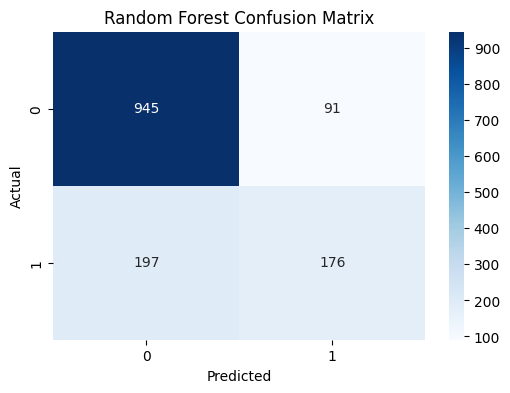

In [31]:
#confusion Matrix
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

**Step 6 — Gradient Boosting Classifier**

In [32]:
# Train Gradient Boosting Model
gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

In [33]:
# Evaluate Gradient Boosting
print("Gradient Boosting Accuracy:",
      accuracy_score(y_test, gb_pred))

print(classification_report(y_test, gb_pred))

Gradient Boosting Accuracy: 0.8055358410220014
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1036
           1       0.67      0.52      0.59       373

    accuracy                           0.81      1409
   macro avg       0.76      0.71      0.73      1409
weighted avg       0.80      0.81      0.80      1409



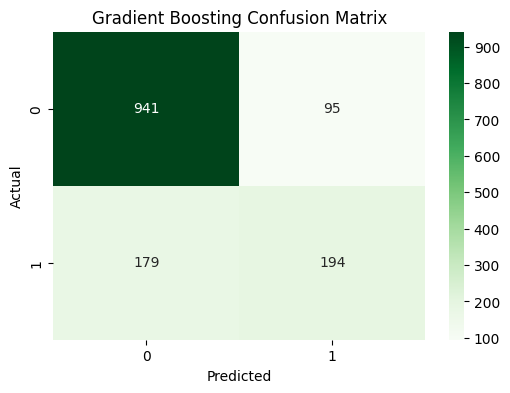

In [34]:
# Confusion Matrix
cm = confusion_matrix(y_test, gb_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Gradient Boosting Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

**Step 7 — Compare All Models**


*   Decision Tree
*   Random Forest

*   Gradient Boosting





In [35]:
models = ["Decision Tree", "Random Forest", "Gradient Boosting"]

scores = [
    accuracy_score(y_test, dt_pred),
    accuracy_score(y_test, rf_pred),
    accuracy_score(y_test, gb_pred)
]

comparison = pd.DataFrame({
    "Model": models,
    "Accuracy": scores
})

comparison

,Model,Accuracy
0,Decision Tree,0.725337
1,Random Forest,0.795600
2,Gradient Boosting,0.805536


**Visualize Model Performance**

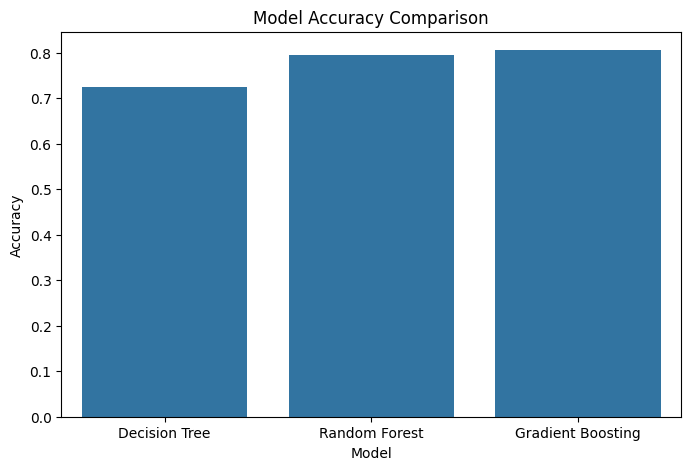

In [36]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=comparison
)

plt.title("Model Accuracy Comparison")

plt.show()

**Step 8 — Hyperparameter Optimization (Random Forest)**

In [38]:
# Define Parameter Grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [39]:
# Run Grid Search
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, None], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='accuracy')

In [40]:
# Best Parameters
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}


In [41]:
# Best Model
best_rf = grid_search.best_estimator_

best_rf_pred = best_rf.predict(X_test)

In [42]:
# Evaluate Optimized Model
print("Optimized Random Forest Accuracy:")

print(
    accuracy_score(y_test, best_rf_pred)
)

print(
    classification_report(y_test, best_rf_pred)
)

Optimized Random Forest Accuracy:
0.8097941802696949
              precision    recall  f1-score   support

           0       0.84      0.91      0.88      1036
           1       0.68      0.52      0.59       373

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409

